In [44]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import sys

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from pathlib import Path
import json

current_path = Path(os.getcwd())
PROJECT_ROOT = current_path.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import core, viz
from src.config import *

pd.reset_option('display.max_rows')

# --- НАСТРОЙКИ ПРОЕКТА ---
SEED = RANDOM_STATE  # Для воспроизводимости результатов
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
os.makedirs(EDA_FIGURES_DIR, exist_ok=True)
df_train = pd.read_csv(TRAIN_DATA, sep=',')
df_test = pd.read_csv(TEST_DATA, sep=',')
os.makedirs(EDA_FIGURES_DIR, exist_ok=True)

In [46]:
# 2. Глубокий анализ через core.py
train_summary = core.summarize_dataset(df_train)
test_summary = core.summarize_dataset(df_test)

print(f"📊 TRAIN: DATASET SHAPE: {train_summary.n_rows} rows x {train_summary.n_cols} columns")
print(f"📊 TEST: DATASET SHAPE: {test_summary.n_rows} rows x {test_summary.n_cols} columns")

📊 TRAIN: DATASET SHAPE: 1460 rows x 81 columns
📊 TEST: DATASET SHAPE: 1459 rows x 80 columns


In [47]:

# Выводим красивую таблицу (используем твой flatten из core)
flat_train = core.flatten_summary_for_print(train_summary)
display(flat_train.head(20))

,name,dtype,non_null,missing,missing_share,unique,is_numeric,min,max,mean,std
0,Id,int64,1460,0,0.000000,1460,True,1.0,1460.0,730.500000,421.610009
1,MSSubClass,int64,1460,0,0.000000,15,True,20.0,190.0,56.897260,42.300571
2,MSZoning,str,1460,0,0.000000,5,False,NaN,NaN,NaN,NaN
3,LotFrontage,float64,1201,259,0.177397,110,True,21.0,313.0,70.049958,24.284752
4,LotArea,int64,1460,0,0.000000,1073,True,1300.0,215245.0,10516.828082,9981.264932
5,Street,str,1460,0,0.000000,2,False,NaN,NaN,NaN,NaN
6,Alley,str,91,1369,0.937671,2,False,NaN,NaN,NaN,NaN
7,LotShape,str,1460,0,0.000000,4,False,NaN,NaN,NaN,NaN
8,LandContour,str,1460,0,0.000000,4,False,NaN,NaN,NaN,NaN
9,Utilities,str,1460,0,0.000000,2,False,NaN,NaN,NaN,NaN


In [48]:
flat_test = core.flatten_summary_for_print(test_summary)
display(flat_test.head())

,name,dtype,non_null,missing,missing_share,unique,is_numeric,min,max,mean,std
0,Id,int64,1459,0,0.000000,1459,True,1461.0,2919.0,2190.000000,421.321334
1,MSSubClass,int64,1459,0,0.000000,16,True,20.0,190.0,57.378341,42.746880
2,MSZoning,str,1455,4,0.002742,5,False,NaN,NaN,NaN,NaN
3,LotFrontage,float64,1232,227,0.155586,115,True,21.0,200.0,68.580357,22.376841
4,LotArea,int64,1459,0,0.000000,1106,True,1470.0,56600.0,9819.161069,4955.517327


In [49]:
all_examples_train = {c.name: c.example_values for c in train_summary.columns}
all_examples_train

{'Id': ['1', '2', '3'],
 'MSSubClass': ['60', '20', '70'],
 'MSZoning': ['RL', 'RM', 'C (all)'],
 'LotFrontage': ['65.0', '80.0', '68.0'],
 'LotArea': ['8450', '9600', '11250'],
 'Street': ['Pave', 'Grvl'],
 'Alley': ['Grvl', 'Pave'],
 'LotShape': ['Reg', 'IR1', 'IR2'],
 'LandContour': ['Lvl', 'Bnk', 'Low'],
 'Utilities': ['AllPub', 'NoSeWa'],
 'LotConfig': ['Inside', 'FR2', 'Corner'],
 'LandSlope': ['Gtl', 'Mod', 'Sev'],
 'Neighborhood': ['CollgCr', 'Veenker', 'Crawfor'],
 'Condition1': ['Norm', 'Feedr', 'PosN'],
 'Condition2': ['Norm', 'Artery', 'RRNn'],
 'BldgType': ['1Fam', '2fmCon', 'Duplex'],
 'HouseStyle': ['2Story', '1Story', '1.5Fin'],
 'OverallQual': ['7', '6', '8'],
 'OverallCond': ['5', '8', '6'],
 'YearBuilt': ['2003', '1976', '2001'],
 'YearRemodAdd': ['2003', '1976', '2002'],
 'RoofStyle': ['Gable', 'Hip', 'Gambrel'],
 'RoofMatl': ['CompShg', 'WdShngl', 'Metal'],
 'Exterior1st': ['VinylSd', 'MetalSd', 'Wd Sdng'],
 'Exterior2nd': ['VinylSd', 'MetalSd', 'Wd Shng'],
 'MasVn

In [50]:
# Сохраняем ПОЛНЫЙ отчет (со всеми пропусками и статистикой)
full_summary_train = train_summary.to_dict()

with open(os.path.join(EDA_DIR, 'full_train_profile.json'), 'w') as f:
    json.dump(full_summary_train, f, indent=4)

In [51]:
miss_train = core.missing_table(df_train)

# Показываем только те колонки, где реально есть дырки (пропуски > 0)
print(f'Всего колонок с пропуском {len(miss_train)}')
display(miss_train)

Всего колонок с пропуском 19


,missing_count,missing_share
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
MasVnrType,872,0.597260
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageQual,81,0.055479
GarageFinish,81,0.055479
GarageType,81,0.055479


In [52]:
miss_test = core.missing_table(df_test)

# Показываем только те колонки, где реально есть дырки (пропуски > 0)
print(f'Всего колонок с пропуском {len(miss_test)}')
display(miss_test)

Всего колонок с пропуском 33


,missing_count,missing_share
PoolQC,1456,0.997944
MiscFeature,1408,0.965045
Alley,1352,0.926662
Fence,1169,0.801234
MasVnrType,894,0.612748
FireplaceQu,730,0.500343
LotFrontage,227,0.155586
GarageYrBlt,78,0.053461
GarageCond,78,0.053461
GarageFinish,78,0.053461


In [53]:
quality_report_train = core.compute_quality_flags(train_summary, miss_train)
display(pd.Series(quality_report_train, name="Quality Metrics Train"))

too_few_rows                                           False
max_missing_share                                   0.995205
avg_missing_share                                   0.066202
too_many_missing                                        True
cols_to_drop_missing            [Alley, PoolQC, MiscFeature]
has_constant_columns                                   False
cols_to_drop_constant                                     []
has_suspicious_id_duplicates                           False
quality_score                                       0.933798
Name: Quality Metrics Train, dtype: object

In [54]:
quality_report_test = core.compute_quality_flags(test_summary, miss_test)
display(pd.Series(quality_report_test, name="Quality Metrics Test"))

too_few_rows                                           False
max_missing_share                                   0.997944
avg_missing_share                                   0.067495
too_many_missing                                        True
cols_to_drop_missing            [Alley, PoolQC, MiscFeature]
has_constant_columns                                    True
cols_to_drop_constant                            [Utilities]
has_suspicious_id_duplicates                           False
quality_score                                       0.832505
Name: Quality Metrics Test, dtype: object

In [55]:
categorical_cols = [col.name for col in train_summary.columns if not col.is_numeric]
numeric_cols = [col.name for col in train_summary.columns if col.is_numeric]

print(f"Категориальных: {len(categorical_cols)}")
print(f"Числовых: {len(numeric_cols)}")

# Выводим только категории
display(df_train[categorical_cols].head())

Категориальных: 43
Числовых: 38


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


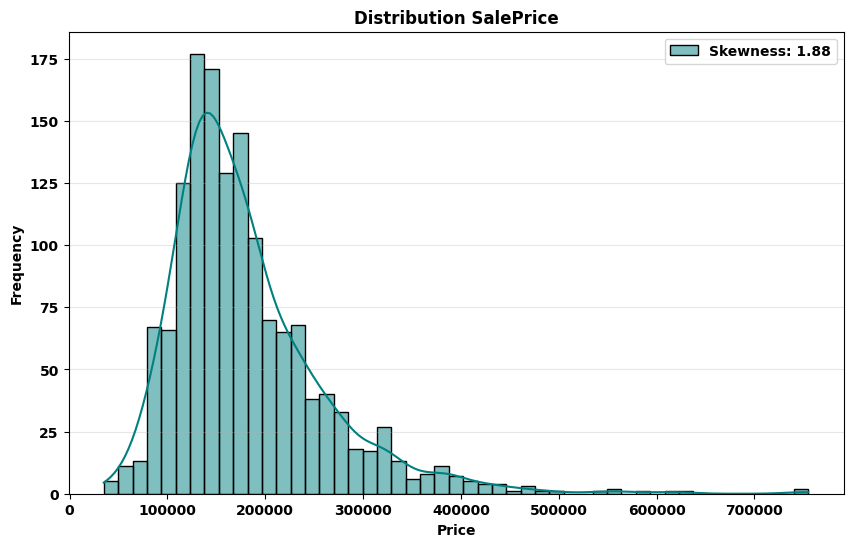

In [56]:
viz.plot_target_distribution(df_train[TARGET], save_path=os.path.join(EDA_FIGURES_DIR, 'target_distribution'))

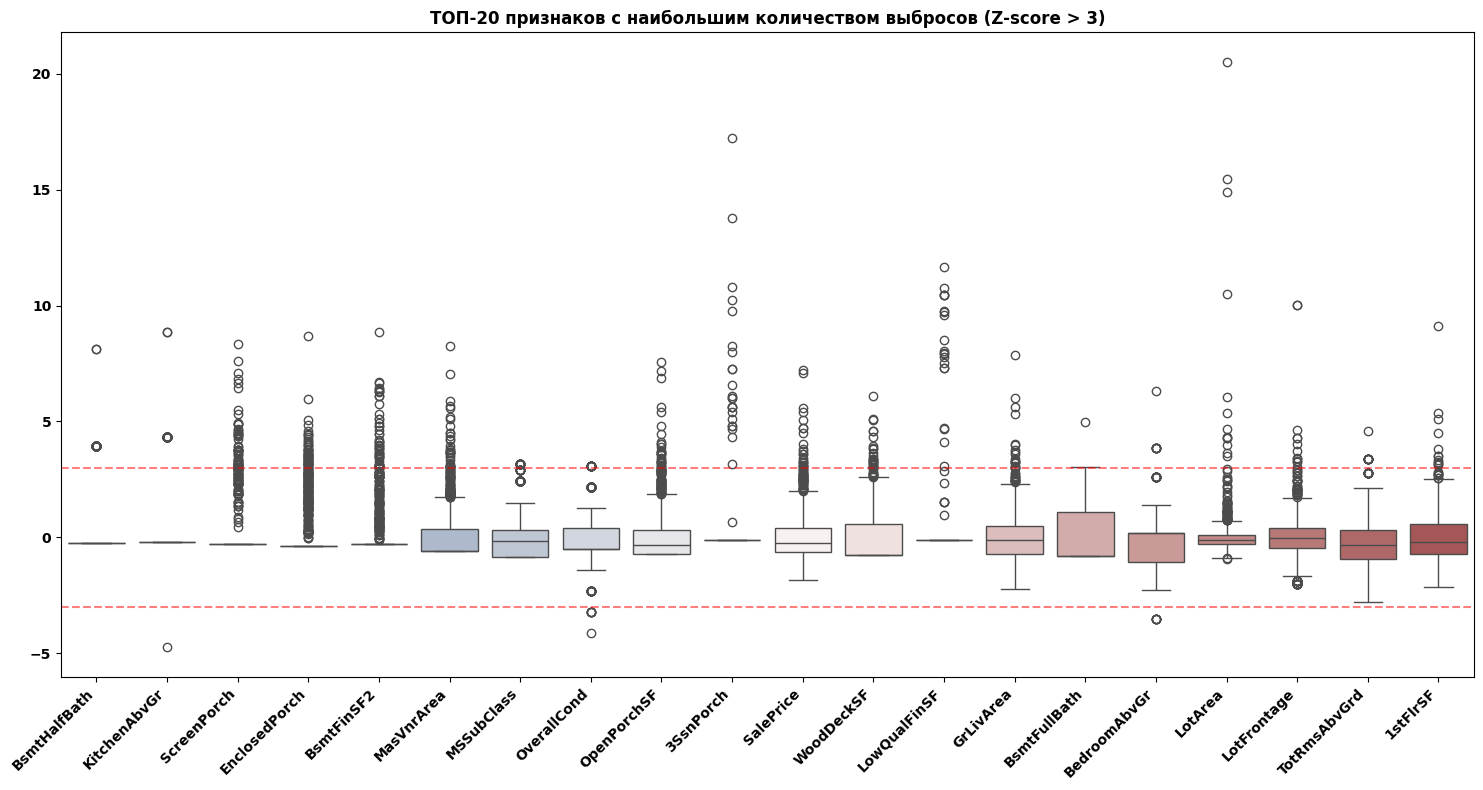

In [57]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_train[numeric_cols]), columns=numeric_cols)

# Считаем количество выбросов для каждой колонки (за пределами 3 сигм)
outliers_count = (np.abs(df_scaled) > 3).sum().sort_values(ascending=False)

# Выводим график только для ТОП-20 признаков с наибольшим количеством выбросов
top_outliers = outliers_count.head(20).index

plt.figure(figsize=(15, 8))
sns.boxplot(data=df_scaled[top_outliers], palette="vlag")
plt.xticks(rotation=45, ha='right')
plt.title("ТОП-20 признаков с наибольшим количеством выбросов (Z-score > 3)")
plt.axhline(y=3, color='r', linestyle='--', alpha=0.5)  # Линия "критической" зоны
plt.axhline(y=-3, color='r', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

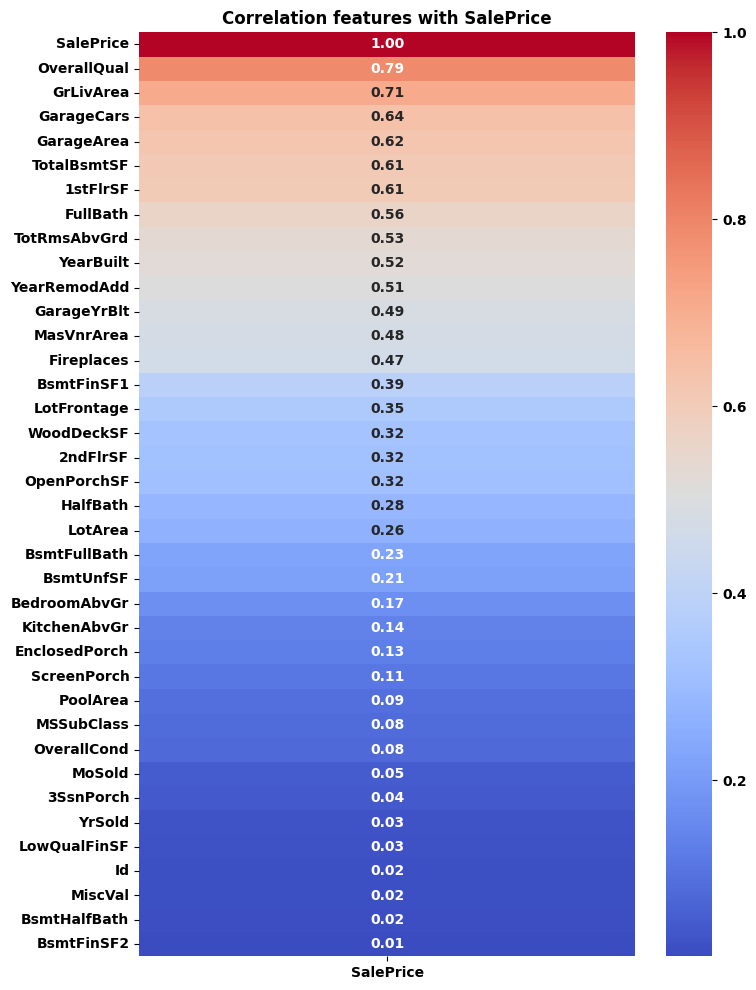

In [58]:
viz.plot_correlation_heatmap(df_train, save_path=os.path.join(EDA_FIGURES_DIR, 'feature_correlation.png'))


In [59]:
print(df_train.drop(TARGET, axis=1).index)
print(df_train[TARGET].index)

RangeIndex(start=0, stop=1460, step=1)
RangeIndex(start=0, stop=1460, step=1)


In [60]:
mi_value = core.get_mi_scores(df_train.drop([TARGET, 'Id'], axis=1), df_train[TARGET], random_state=RANDOM_STATE)

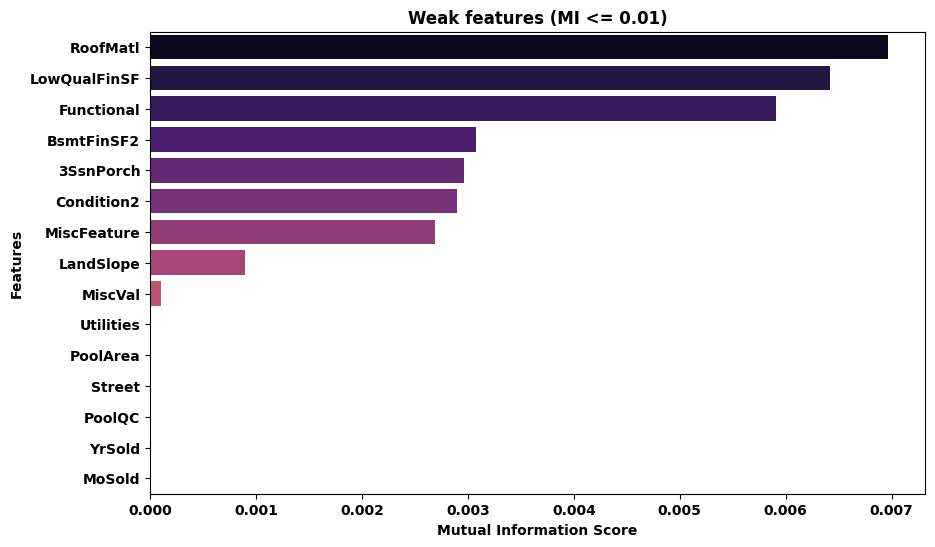

In [61]:
viz.plot_mi_scores(mi_value, mode = 'weak', threshold=0.01, save_path=os.path.join(EDA_FIGURES_DIR, 'mi_scores_weak.png'))

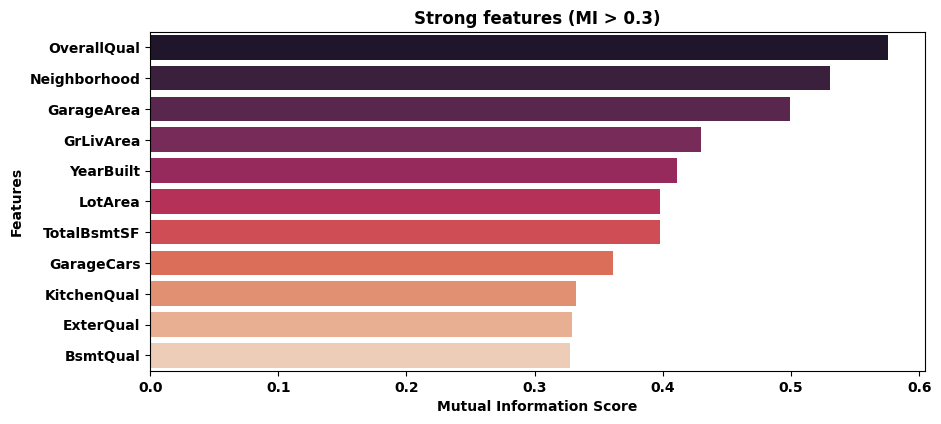

In [62]:
viz.plot_mi_scores(mi_value, mode = 'strong', threshold=0.3, save_path=os.path.join(EDA_FIGURES_DIR, 'mi_scores_strong.png'))

In [63]:
importance_cat_col = core.get_important_categories(df_train, categorical_cols)
importance_cat_col

Index(['ExterQual', 'KitchenQual', 'BsmtQual', 'GarageFinish', 'Foundation',
       'CentralAir', 'HeatingQC', 'Neighborhood', 'GarageType',
       'BsmtExposure'],
      dtype='str')

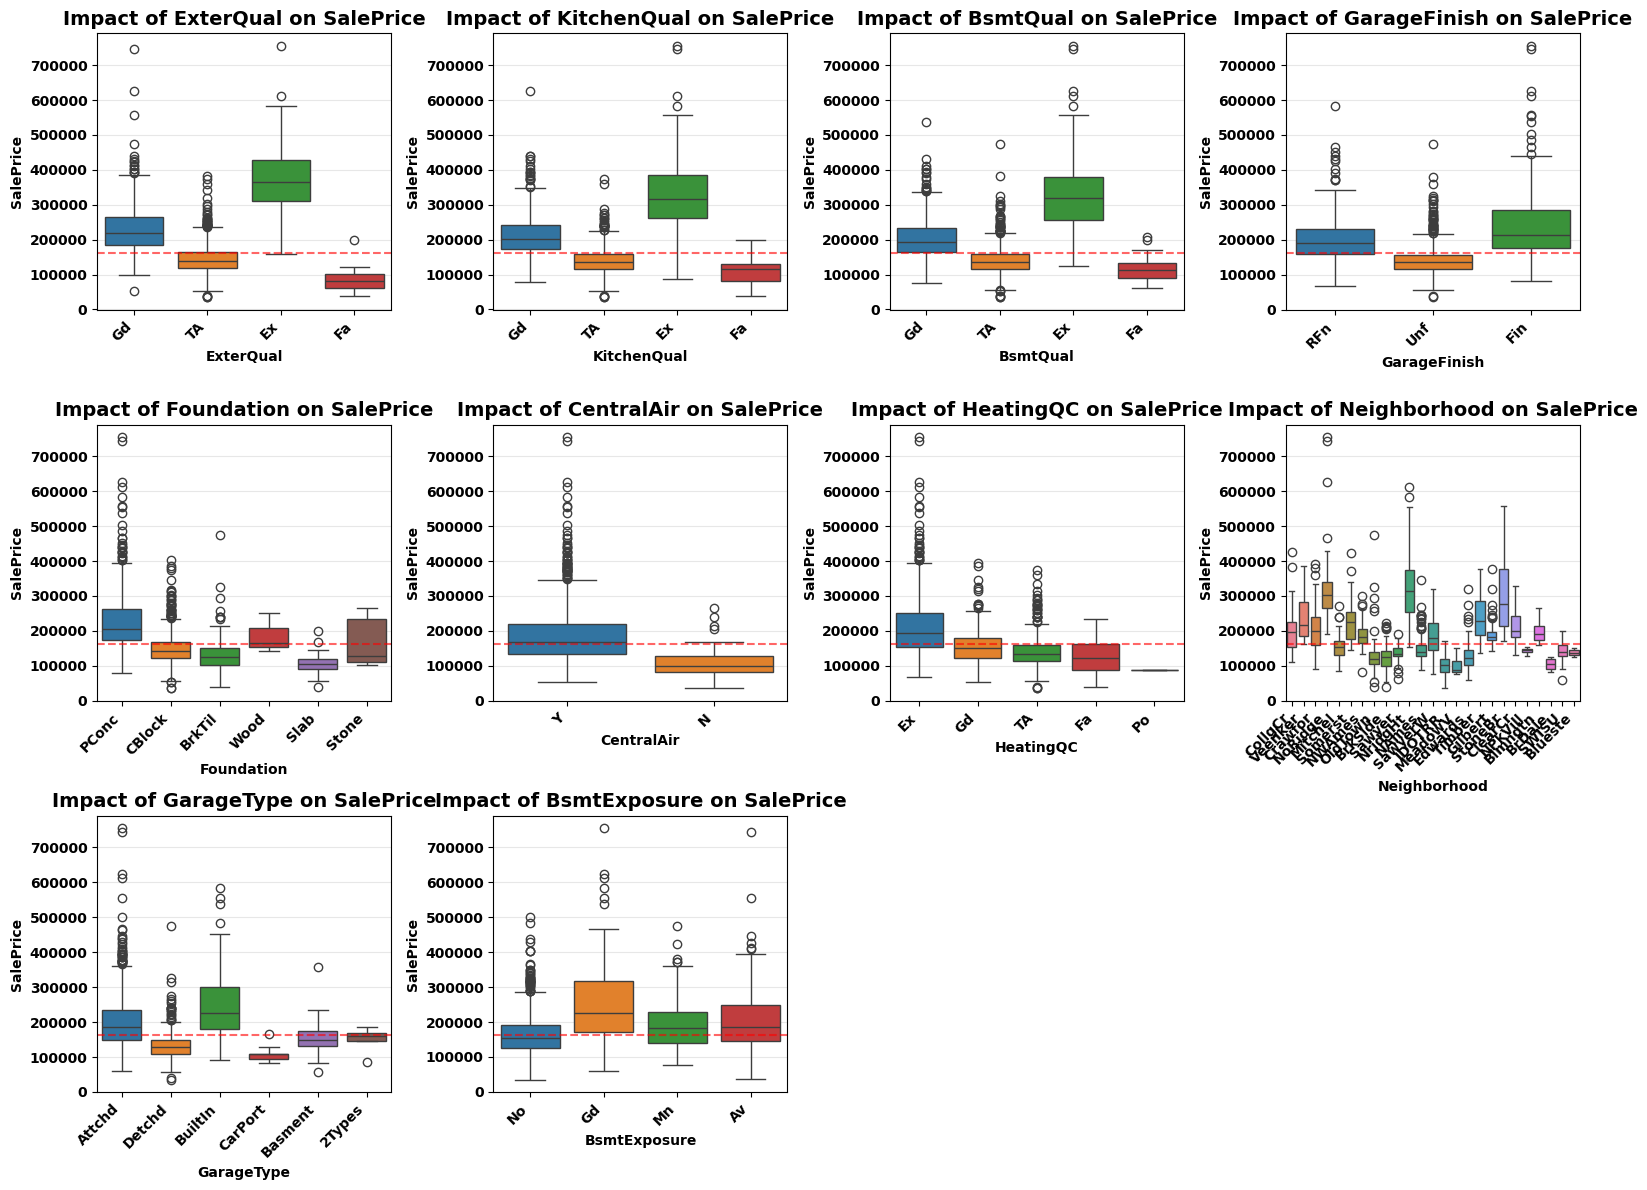

In [64]:
viz.plot_categorical_impact(df_train, importance_cat_col, save_path=os.path.join(EDA_FIGURES_DIR, 'categorical_impact.png'))

In [65]:
low_cat_cols = core.get_low_variance_report(df_train, threshold=0.9)
low_cat_cols

,feature,dominant_value,share_%,unique_count
0,Utilities,AllPub,99.93,2
1,Street,Pave,99.59,2
2,PoolArea,0,99.52,8
3,Condition2,Norm,98.97,8
4,3SsnPorch,0,98.36,20
5,LowQualFinSF,0,98.22,24
6,RoofMatl,CompShg,98.22,8
7,Heating,GasA,97.81,6
8,MiscVal,0,96.44,21
9,GarageCond,TA,96.16,5


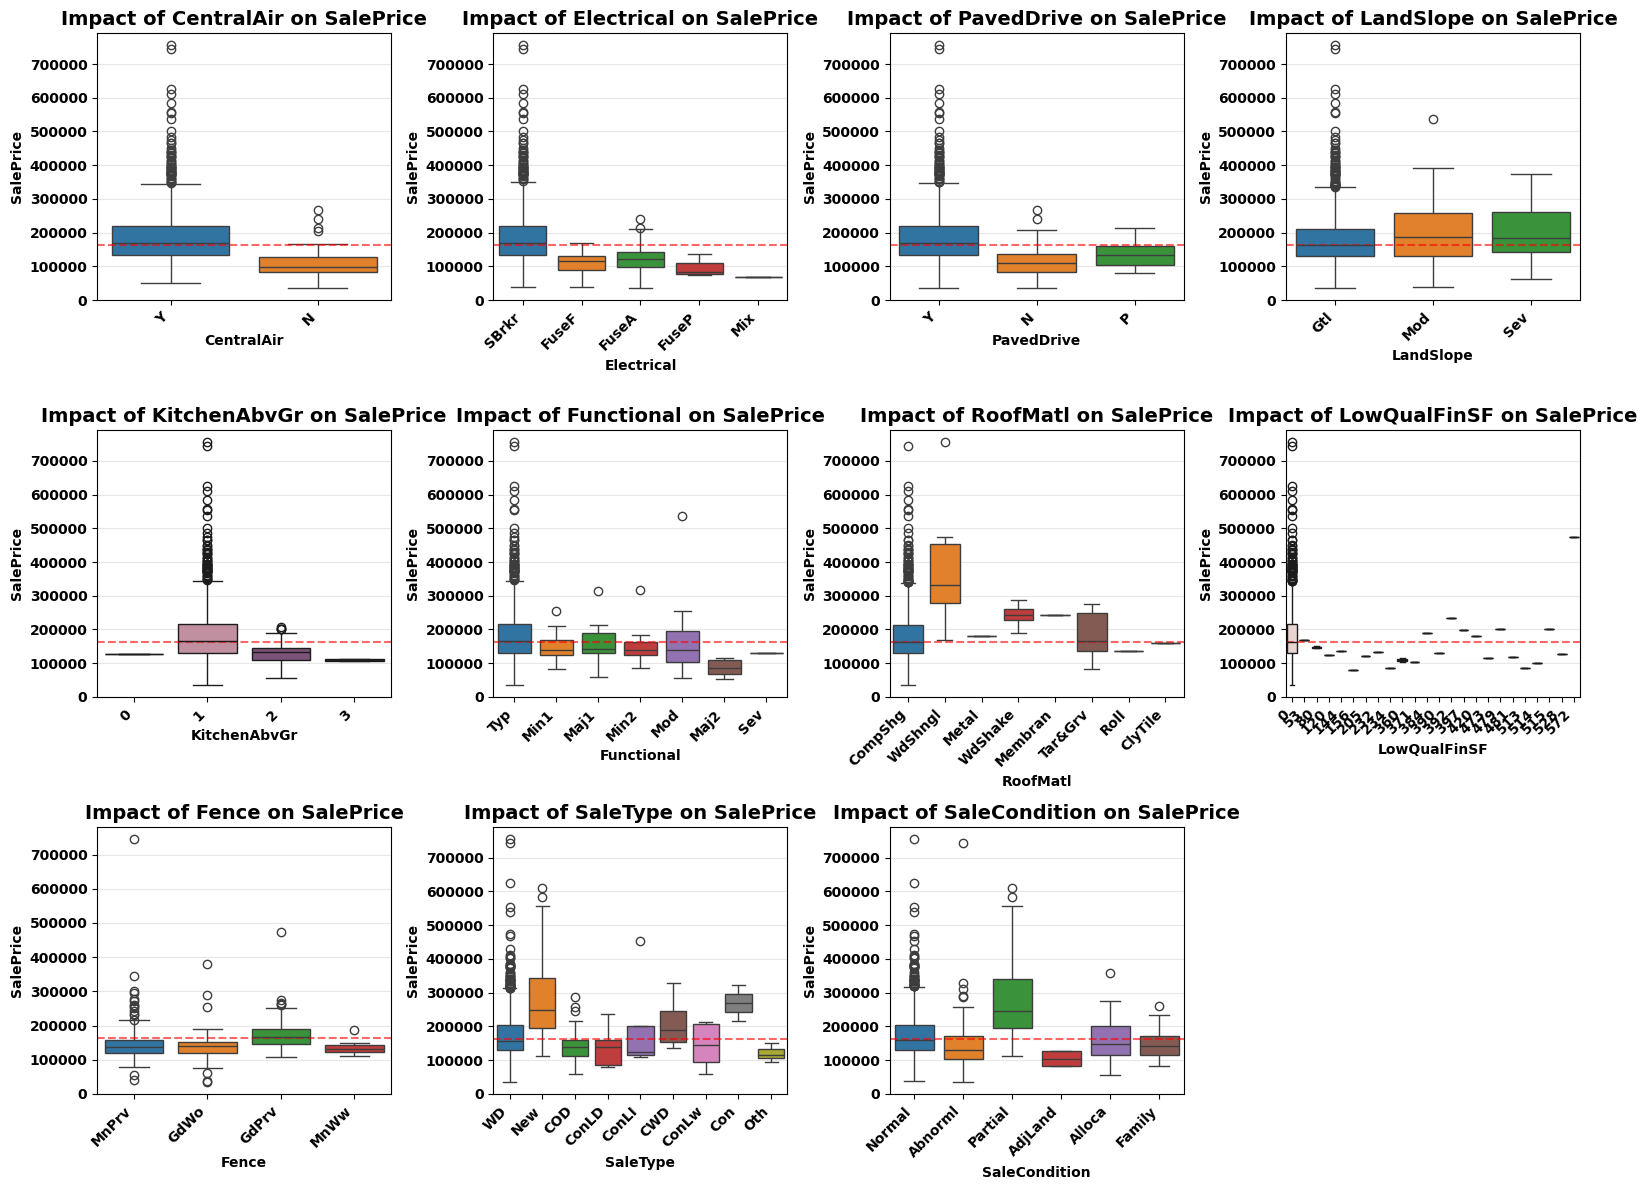

In [26]:
cols_to_check = ['CentralAir', 'Electrical', 'PavedDrive', 'LandSlope', 'KitchenAbvGr', 'Functional', 
                 'RoofMatl', 'LowQualFinSF', 'Fence', 'SaleType', 'SaleCondition'] 
viz.plot_categorical_impact(df_train, cols_to_check, figsize=(20,20), save_path=os.path.join(EDA_FIGURES_DIR, 'cat_low_cardinality.png'))

In [27]:
df_train[df_train['LowQualFinSF'] > 550][['GrLivArea', 'OverallQual', 'OverallCond', 'Neighborhood']]


,GrLivArea,OverallQual,OverallCond,Neighborhood
185,3608,10,9,OldTown


In [28]:
df_train[(df_train['Functional'] == 'Mod') & (df_train['SalePrice'] > 400000)][['GrLivArea', 'OverallQual', 'OverallCond', 'Neighborhood']]

,GrLivArea,OverallQual,OverallCond,Neighborhood
769,3279,8,5,StoneBr


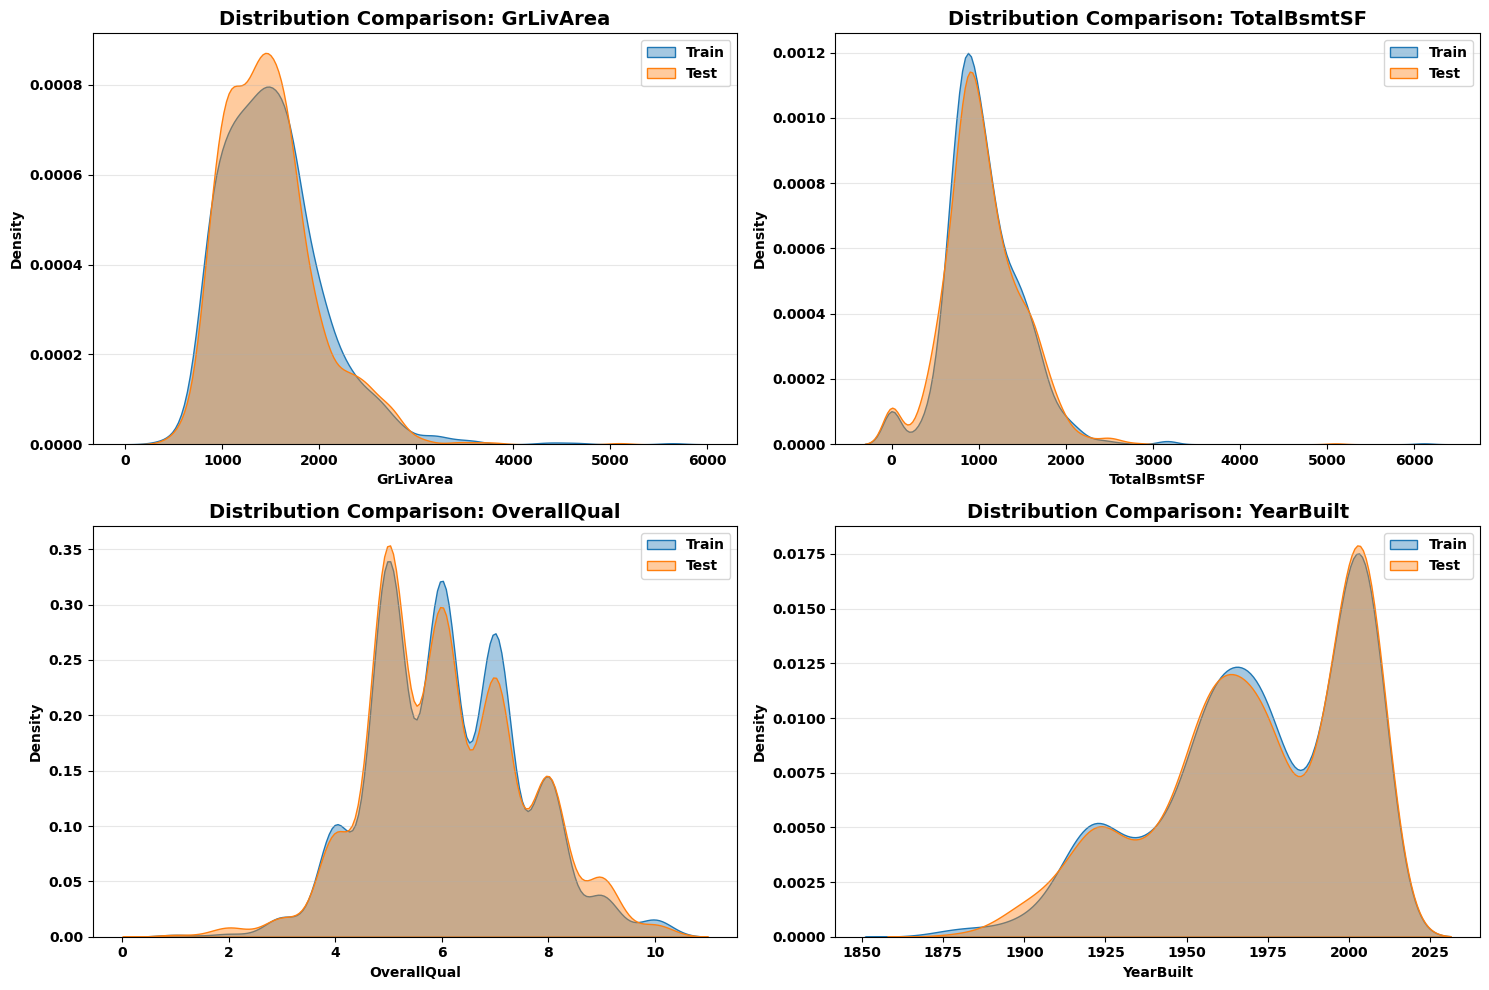

In [29]:
features_to_check = ['GrLivArea', 'TotalBsmtSF', 'OverallQual', 'YearBuilt']

viz.plot_train_test_drift(df_train, df_test, features_to_check, save_path=os.path.join(EDA_FIGURES_DIR, 'validation_train_test_drift.png'))

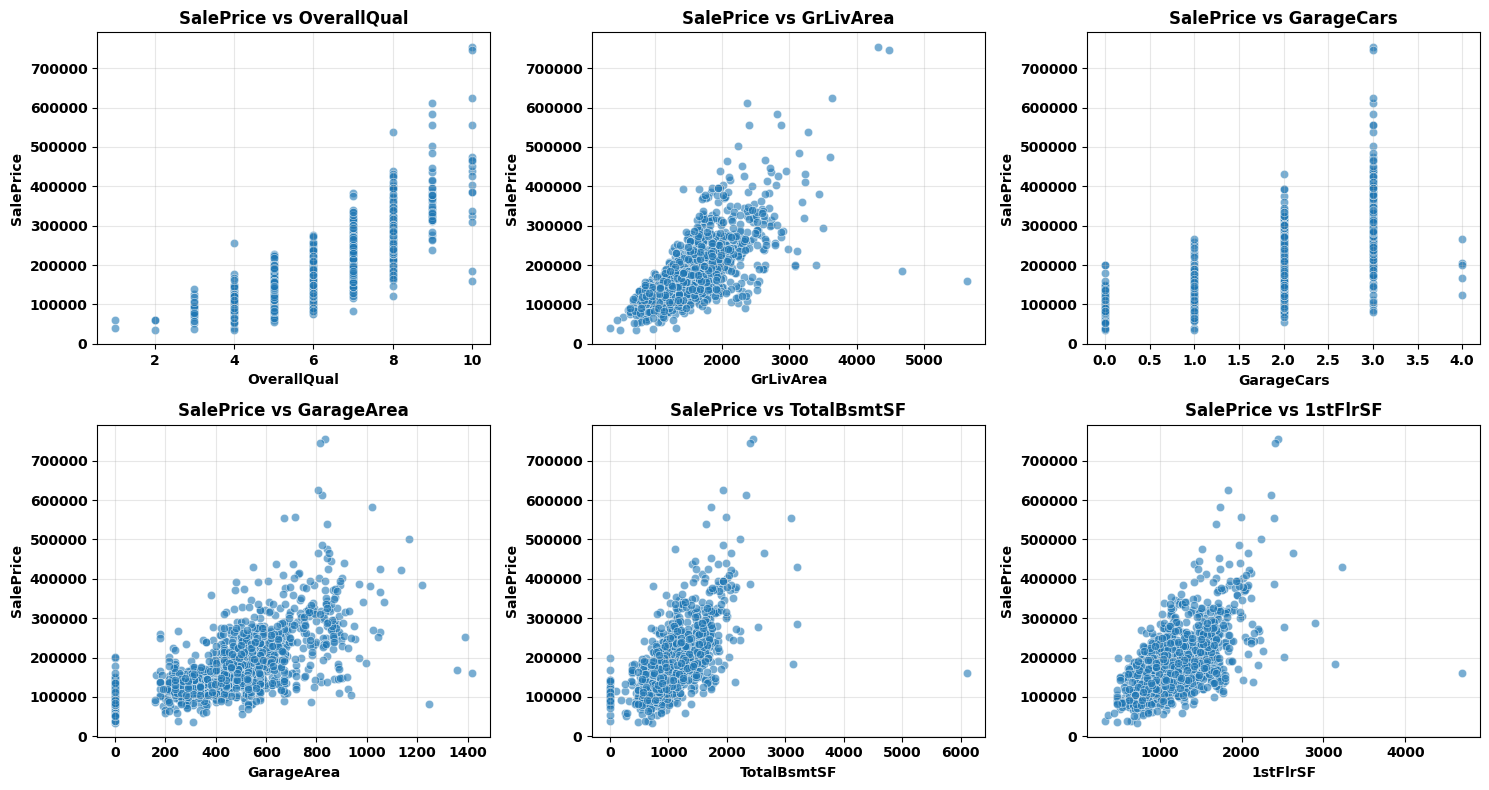

In [30]:
viz.plot_top_scatter(df_train, TARGET, save_path=os.path.join(EDA_FIGURES_DIR, "analysis_top_numeric_scatter.png"))

In [31]:
df_train[(df_train['SalePrice'] < 250000) & (df_train['GrLivArea'] > 4000)] #явные аномалии слишком маленькая цена для такой площади

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


In [32]:
df_train[(df_train['SalePrice'] < 250000) & (df_train['TotalBsmtSF'] > 5500)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


In [33]:
df_train[(df_train['SalePrice'] < 250000) & (df_train['OverallQual'] == 10)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


In [34]:
df_train[(df_train['SalePrice'] > 200000) & (df_train['OverallQual'] == 4)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
457,458,20,RL,NaN,53227,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,3,2008,WD,Normal,256000


In [35]:
core.missing_table(df_train)

,missing_count,missing_share
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
MasVnrType,872,0.597260
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageQual,81,0.055479
GarageFinish,81,0.055479
GarageType,81,0.055479


In [36]:
# 1. Получаем таблицы пропусков
train_miss = core.missing_table(df_train)
test_miss = core.missing_table(df_test)

comparison = train_miss.merge(
    test_miss, 
    left_index=True, 
    right_index=True, 
    how='outer', 
    suffixes=('_train', '_test')
).fillna(0)

# 3. Фильтруем: в Train пропусков 0, а в Test > 0
new_missing_in_test = comparison[
    (comparison['missing_count_train'] == 0) & 
    (comparison['missing_count_test'] > 0)
]

display(new_missing_in_test)

,missing_count_train,missing_share_train,missing_count_test,missing_share_test
BsmtFinSF1,0.0,0.0,1.0,0.000685
BsmtFinSF2,0.0,0.0,1.0,0.000685
BsmtFullBath,0.0,0.0,2.0,0.001371
BsmtHalfBath,0.0,0.0,2.0,0.001371
BsmtUnfSF,0.0,0.0,1.0,0.000685
Exterior1st,0.0,0.0,1.0,0.000685
Exterior2nd,0.0,0.0,1.0,0.000685
Functional,0.0,0.0,2.0,0.001371
GarageArea,0.0,0.0,1.0,0.000685
GarageCars,0.0,0.0,1.0,0.000685


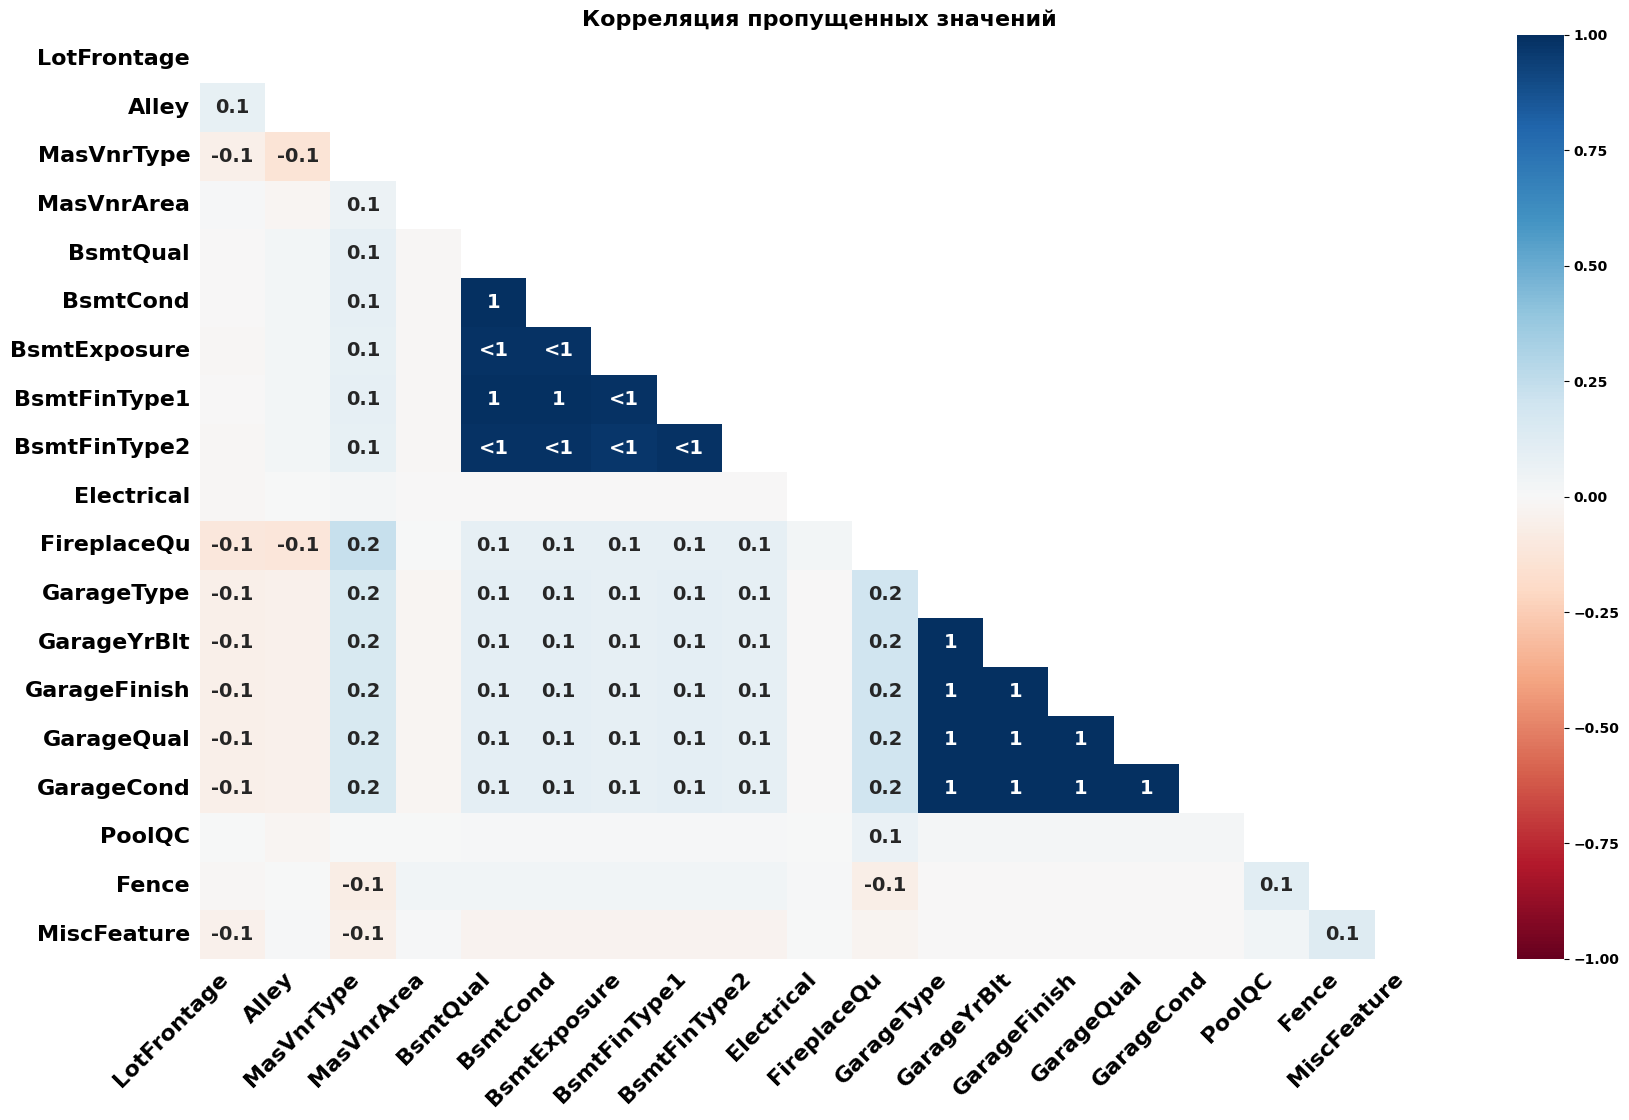

In [37]:
# тепловая карта корреляции отсутствия данных.  
viz.plot_missing_correlation(df_train, save_path=os.path.join(EDA_FIGURES_DIR,'analysis_missing_data_correlation'))

In [38]:
core.check_categorical_redundancy(df_train)

,feat1,feat2,match_ratio,uniques_f1,uniques_f2
7,GarageQual,GarageCond,0.9041,5,5
6,CentralAir,PavedDrive,0.9034,2,3
0,Condition1,Condition2,0.8664,9,8
1,Exterior1st,Exterior2nd,0.8527,15,16
5,BsmtCond,GarageCond,0.8356,4,5
2,ExterCond,BsmtCond,0.8267,5,4
4,BsmtCond,GarageQual,0.8178,4,5
3,ExterCond,GarageCond,0.8103,5,5


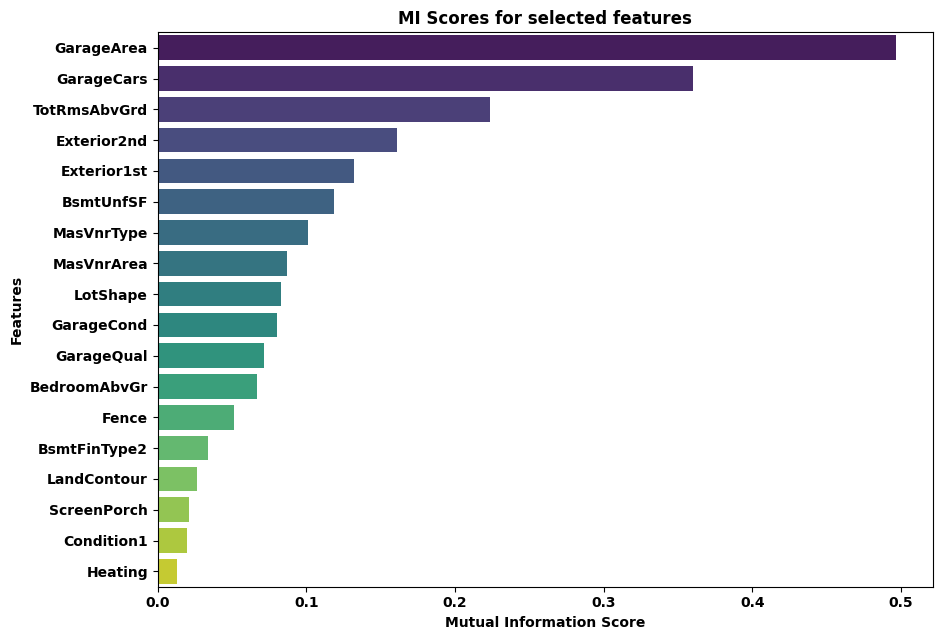

In [39]:
target_features = ['GarageQual', 'GarageCond', 'Condition1', 'ScreenPorch', 'Fence', 'MasVnrArea', 'BsmtFinType2', 'BsmtUnfSF', 'TotRmsAbvGrd',
                     'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Heating', 'BedroomAbvGr', 'GarageCars', 'GarageArea', 'LandContour', 'LotShape']
check_features = core.get_mi_scores(df_train[target_features], df_train[TARGET])
viz.plot_mi_scores(check_features, target_features, df_train[TARGET])

In [40]:
df_train['SaleType'].value_counts(normalize=True)

SaleType
WD       0.867808
New      0.083562
COD      0.029452
ConLD    0.006164
ConLI    0.003425
ConLw    0.003425
CWD      0.002740
Oth      0.002055
Con      0.001370
Name: proportion, dtype: float64

In [41]:
df_train.SaleCondition.value_counts(normalize=True)

SaleCondition
Normal     0.820548
Partial    0.085616
Abnorml    0.069178
Family     0.013699
Alloca     0.008219
AdjLand    0.002740
Name: proportion, dtype: float64

In [42]:
with open(os.path.join(TRAIN_PARAMS_DIR, 'data_params.yaml'), 'r', encoding='utf-8') as f:
        params = yaml.safe_load(f)

In [43]:
df_train.drop(params['cols_to_drop'], axis=1)

,Id,MSSubClass,MSZoning,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,BldgType,HouseStyle,...,GarageFinish,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,EnclosedPorch,SaleType,SaleCondition,SalePrice
0,1,60,RL,Reg,Lvl,Inside,Gtl,CollgCr,1Fam,2Story,...,RFn,548,TA,TA,Y,0,0,WD,Normal,208500
1,2,20,RL,Reg,Lvl,FR2,Gtl,Veenker,1Fam,1Story,...,RFn,460,TA,TA,Y,298,0,WD,Normal,181500
2,3,60,RL,IR1,Lvl,Inside,Gtl,CollgCr,1Fam,2Story,...,RFn,608,TA,TA,Y,0,0,WD,Normal,223500
3,4,70,RL,IR1,Lvl,Corner,Gtl,Crawfor,1Fam,2Story,...,Unf,642,TA,TA,Y,0,272,WD,Abnorml,140000
4,5,60,RL,IR1,Lvl,FR2,Gtl,NoRidge,1Fam,2Story,...,RFn,836,TA,TA,Y,192,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,Reg,Lvl,Inside,Gtl,Gilbert,1Fam,2Story,...,RFn,460,TA,TA,Y,0,0,WD,Normal,175000
1456,1457,20,RL,Reg,Lvl,Inside,Gtl,NWAmes,1Fam,1Story,...,Unf,500,TA,TA,Y,349,0,WD,Normal,210000
1457,1458,70,RL,Reg,Lvl,Inside,Gtl,Crawfor,1Fam,2Story,...,RFn,252,TA,TA,Y,0,0,WD,Normal,266500
1458,1459,20,RL,Reg,Lvl,Inside,Gtl,NAmes,1Fam,1Story,...,Unf,240,TA,TA,Y,366,112,WD,Normal,142125
